<center><h2 style="color:#0000ff; font-family:Georgia;"><b>DATA 645. Neural Networks and Deep Learning</b></h2>
<h2 style="color:#ff0000; font-family:'Calibri';">Module 6 Homework Lab</h2>
<h1 style="color:#9933cc; font-family:Arial;"><b>Effect of Hyperparameters<br></b></h1></center>


In this lab assignment, you will implement a simple neural network for a binary classification problem using TensorFlow. Instead of merely implementing the backpropagation algorithm, you'll extend the last week's lab by including the hyperparameter optimization to enhance the model's performance.

**Task Description:**
Consider a binary classification problem involving two classes, denoted as $\omega_1(+1)$ and $\omega_2(-1)$. Each class is modeled by a mixture of equiprobable Gaussian distributions. Specifically, the means of the Gaussians associated with $\omega_1$ are located at $[-5,5]^{\top}$ and $[5,-5]^{\top}$, while the means of the Gaussians associated with $\omega_2$ are situated at $[-5,-5]^{\top}$, $[0,0]^{\top}$, and $[5,5]^{\top}$. All Gaussians share the same covariance $\sigma^2{\bf I}$, where $\sigma^2 = 1$.

**Exercise 1: Generate and Prepare the Data**

Generate 2-dimensional data points for both training and testing sets. For the training set $X_{\text{train}}$, create 10,000 points from $\omega_1$ and 10,000 points from $\omega_2$. Similarly, generate 2,000 testing points and store them in $X_{\text{test}}$. Ensure the correct labeling of the data points.

**Exercise 2: Neural Network Training and Evaluation**

Train a neural network on the training set $X_{\text{train}}$ with the goal of binary classification. Utilize TensorFlow for implementation. While training, conduct hyperparameter optimization to enhance the model's performance. Once trained, evaluate the model's accuracy on both the training and testing sets ($X_{\text{train}}$ and $X_{\text{test}}$ respectively). 

**Exercise 3: Observations and Analysis**

Run the model multiple times, at least three, and observe the variations in the testing accuracy. Analyze the factors contributing to these differences. Consider the impact of hyperparameters such as learning rate, batch size, and network architecture, as well as the random initialization of weights. 

By completing these exercises, you will gain practical experience in training neural networks for binary classification tasks using TensorFlow, while also exploring the importance of hyperparameter optimization in enhancing model performance and stability.

### Exercise 1: Generate and Prepare the Data
#### Generate 2-dimensional data points for both training and testing sets. 
#### For the training set $X_{\text{train}}$, create 10,000 points from $\omega_1$ and 10,000 points from $\omega_2$. 
#### Similarly, generate 2,000 testing points and store them in $X_{\text{test}}$. Ensure the correct labeling of the data points.

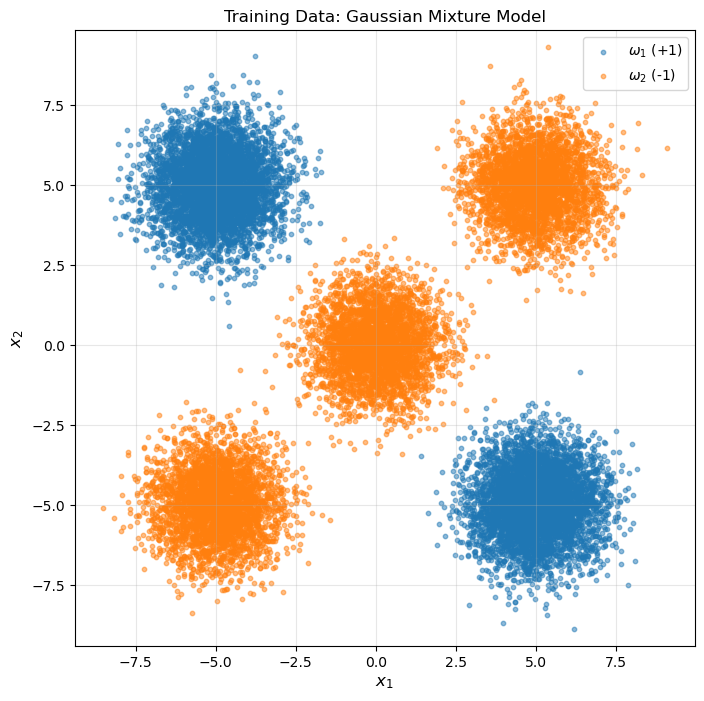

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Set initial variables
rng = np.random.default_rng(42)
sigma = 1.0

# Create a 2x2 covariance matrix. 
# Each gaussian is circular so that the data for each class will be spread 
# equally from the mean and independent from each other (as demanded by the exercise).
cov = sigma**2 * np.eye(2)

# Class Sizes
n_train_per_class = 10000
n_test_per_class = 1000

# Helper to split integer counts so they sum to N
def split_counts(N, k):
    base = N // k
    rem = N - base * k
    return [base + (1 if i < rem else 0) for i in range(k)]

# Generate training data for w1 
means_w1 = [np.array([-5.0, 5.0]), np.array([5.0, -5.0])]
sizes_w1 = split_counts(n_train_per_class, len(means_w1))
Xw1_train = np.vstack([rng.multivariate_normal(m, cov, size=s) for m, s in zip(means_w1, sizes_w1)])

# Generate training data for w2 
means_w2 = [np.array([-5.0, -5.0]), np.array([0.0, 0.0]), np.array([5.0, 5.0])]
sizes_w2 = split_counts(n_train_per_class, len(means_w2))
Xw2_train = np.vstack([rng.multivariate_normal(m, cov, size=s) for m, s in zip(means_w2, sizes_w2)])

# Combine training data and create labels 
X_train = np.vstack([Xw1_train, Xw2_train]).astype(np.float32)
y_train = np.hstack([np.ones(len(Xw1_train)), -np.ones(len(Xw2_train))]).astype(np.float32)

# Shuffle training data
perm = rng.permutation(len(X_train))
X_train, y_train = X_train[perm], y_train[perm]

# Generate testing data (same mixture proportions)
sizes_w1_test = split_counts(n_test_per_class, len(means_w1))
sizes_w2_test = split_counts(n_test_per_class, len(means_w2))
Xw1_test = np.vstack([rng.multivariate_normal(m, cov, size=s) for m, s in zip(means_w1, sizes_w1_test)])
Xw2_test = np.vstack([rng.multivariate_normal(m, cov, size=s) for m, s in zip(means_w2, sizes_w2_test)])

# Combine test data and create labels
X_test = np.vstack([Xw1_test, Xw2_test]).astype(np.float32)
y_test = np.hstack([np.ones(len(Xw1_test)), -np.ones(len(Xw2_test))]).astype(np.float32)

# Shuffle test data
perm_test = rng.permutation(len(X_test))
X_test, y_test = X_test[perm_test], y_test[perm_test]

# Plot training data
plt.figure(figsize=(8, 8))
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], alpha=0.5, s=10, label=r'$\omega_1$ (+1)')
plt.scatter(X_train[y_train==-1, 0], X_train[y_train==-1, 1], alpha=0.5, s=10, label=r'$\omega_2$ (-1)')
plt.xlabel('$x_1$', fontsize=12)
plt.ylabel('$x_2$', fontsize=12)
plt.title('Training Data: Gaussian Mixture Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

*Exercise 2: Neural Network Training and Evaluation*
#### Train a neural network on the training set $X_{\text{train}}$ with the goal of binary classification. 
#### Utilize TensorFlow for implementation. 
#### While training, conduct hyperparameter optimization to enhance the model's performance. 
#### Once trained, evaluate the model's accuracy on both the training and testing sets ($X_{\text{train}}$ and $X_{\text{test}}$ respectively). 

In [50]:
# Convert labels from [-1, 1} to {0, 1} for binary crossentropy. 
y_train_bin = ((y_train + 1) / 2).astype(np.float32)
y_test_bin = ((y_test + 1) / 2).astype(np.float32)

In [51]:
# Convert to float32 for tensorflow
X_train_tf = tf.convert_to_tensor(X_train, dtype = tf.float32)
X_test_tf = tf.convert_to_tensor(X_test, dtype = tf.float32)
y_train_tf = tf.convert_to_tensor(y_train_bin, dtype = tf.float32)
y_test_tf = tf.convert_to_tensor(y_test_bin, dtype = tf.float32)

In [53]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model(hp):
    units = hp.Int(name="units", min_value=16, max_value=64, step=16)
    model = keras.Sequential([
        layers.Dense(units, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    optimizer = hp.Choice(name="optimizer", values=["rmsprop", "adam"])
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"])
    return model

In [54]:

import keras_tuner as kt

class SimpleMLP(kt.HyperModel):
    def __init__(self, num_classes):
        self.num_classes = num_classes

    def build(self, hp):
        units = hp.Int(name="units", min_value=16, max_value=64, step=16)
        model = keras.Sequential([
            layers.Dense(units, activation="relu"),
            layers.Dense(1, activation="sigmoid")
        ])
        optimizer = hp.Choice(name="optimizer", values=["rmsprop", "adam"])
        model.compile(
            optimizer=optimizer,
            loss="binary_crossentropy",
            metrics=["accuracy"])
        return model

hypermodel = SimpleMLP(num_classes=2)

In [56]:
tuner = kt.BayesianOptimization(
    build_model,
    objective="val_accuracy",
    max_trials=10, #change to something larger e.g.100
    executions_per_trial=2,
    directory=".",
    overwrite=True,
)

In [57]:
X_train_full = X_train_tf[:]
y_train_full = y_train_tf[:]
num_val_samples = 10000
X_train_f, X_val = X_train_tf[:-num_val_samples], X_train_tf[-num_val_samples:]
y_train_f, y_val = y_train_tf[:-num_val_samples], y_train_tf[-num_val_samples:]

In [58]:
# Tunersearch

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5),
]
tuner.search(
    X_train_f, y_train_f,  
    batch_size=128,
    epochs=100,
    validation_data=(X_val, y_val),  
    callbacks=callbacks,
    verbose=2,
)

Trial 10 Complete [00h 01m 00s]
val_accuracy: 0.9998000264167786

Best val_accuracy So Far: 0.9998999834060669
Total elapsed time: 00h 08m 24s


In [65]:
best_model = tuner.get_best_models(num_models=1)[0]

In [66]:
test_loss, test_accuracy = best_model.evaluate(X_test_tf, y_test_tf)
print(f"Test Accuracy: {test_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0093 
Test Accuracy: 1.0


An accuracy of 1.0 is disturbingly precise, but let's remember that our data set is synthetic with clear, non-overlapping boundaries. 

*Exercise 3: Observations and Analysis*


In [67]:
# Train the best model configuration multiple times with different random initializations
results = []
for run in range(3):
    # Build a fresh model with the best hyperparameters
    model = hypermodel.build(best_hps)
    
    # Train the model
    model.fit(X_train_f, y_train_f, 
              batch_size=128, epochs=100,
              validation_data=(X_val, y_val),
              verbose=0)
    
    # Evaluate on test set
    test_loss, test_acc = model.evaluate(X_test_tf, y_test_tf, verbose=0)
    results.append(test_acc)
    print(f"Run {run+1}: Test Accuracy = {test_acc:.4f}")

print(f"\n=== Summary ===")
print(f"Mean Test Accuracy: {np.mean(results):.4f}")
print(f"Std Dev: {np.std(results):.4f}")
print(f"Min: {np.min(results):.4f}, Max: {np.max(results):.4f}")

Run 1: Test Accuracy = 1.0000
Run 2: Test Accuracy = 1.0000
Run 3: Test Accuracy = 1.0000

=== Summary ===
Mean Test Accuracy: 1.0000
Std Dev: 0.0000
Min: 1.0000, Max: 1.0000


## Analysis and Observations

All three models have a perfect accuracy. This is highly unusual. However, it is likely due to the nature of the synthetic dataset. In Lab 5, the model built on this data was able to achieve training accuracy of .9998, 0.9999, and 0.9999 for its three training runs. It achieved Test accuracy of 0.9995, 1.0, and 1.0 on its test accuracy. The current approach was possibly able to achieve perfect accuracy on the testing data based on the hyperparameter tuning. However, it is also possible that its improved performance is due to the randomness (different starts, stochastic descent) that are built into the training proces.